In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))    # chạy notebook từ thư mục notebooks/

import matplotlib.pyplot as plt
from src.config import N_HEADS, REPORTS, set_seed
from src.data import nap_du_lieu
from src.report import bang_ket_qua
from src.train import build_lstm, build_transformer, chay_keras, luu_vocab, ma_hoa, tao_vectorizer
set_seed()

In [2]:
data = nap_du_lieu()
vec = tao_vectorizer(data["texts"]["train"])
luu_vocab(vec)                     # notebook 04 cần cùng từ điển để vẽ attention
ids = ma_hoa(vec, data)
print({k: v.shape for k, v in ids.items()})

{'train': (108000, 64), 'val': (12000, 64), 'test': (7600, 64)}


In [3]:
chay_keras("lstm", build_lstm(), vec, data, ids)

Epoch 1/8
844/844 - 108s - 127ms/step - accuracy: 0.8843 - loss: 0.3364 - val_accuracy: 0.9232 - val_loss: 0.2415
Epoch 2/8
844/844 - 124s - 147ms/step - accuracy: 0.9348 - loss: 0.1936 - val_accuracy: 0.9183 - val_loss: 0.2473
Epoch 3/8
844/844 - 144s - 171ms/step - accuracy: 0.9498 - loss: 0.1480 - val_accuracy: 0.9134 - val_loss: 0.2657
{'model': 'lstm', 'accuracy': 0.9182894736842105, 'macro_f1': 0.9183262773708691, 'train_seconds': 376.2685672999942, 'params': 2659332, 'predict_ms': 2028.6642530001702, 'val_accuracy': 0.9231666922569275}


{'model': 'lstm',
 'accuracy': 0.9182894736842105,
 'macro_f1': 0.9183262773708691,
 'train_seconds': 376.2685672999942,
 'params': 2659332,
 'predict_ms': 2028.6642530001702,
 'val_accuracy': 0.9231666922569275}

In [4]:
model = build_transformer()
model.summary()
chay_keras("transformer_tu_xay", model, vec, data, ids)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_va_vi_tri     │ (None, 64, 128)   │  2,560,000 │ input_layer_1[0]… │
│ (TokenVaViTri)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ khoi_transformer    │ (None, 64, 128)   │    132,480 │ token_va_vi_tri[… │
│ (KhoiTransformer)   │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ khoi_transformer_1  │ (None, 64, 128)   │    132,480 │ khoi_transformer… │
│ (KhoiTransformer)   │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ khoi_transformer… │
│ (GlobalAveragePool… │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 4)         │        516 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,825,476 (10.78 MB)

 Trainable params: 2,825,476 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
844/844 - 466s - 552ms/step - accuracy: 0.8785 - loss: 0.3382 - val_accuracy: 0.9218 - val_loss: 0.2349
Epoch 2/8
844/844 - 485s - 575ms/step - accuracy: 0.9409 - loss: 0.1698 - val_accuracy: 0.9208 - val_loss: 0.2507
Epoch 3/8
844/844 - 443s - 525ms/step - accuracy: 0.9605 - loss: 0.1106 - val_accuracy: 0.9117 - val_loss: 0.3000
{'model': 'transformer_tu_xay', 'accuracy': 0.9163157894736842, 'macro_f1': 0.9158953441663682, 'train_seconds': 1394.1513215999585, 'params': 2825476, 'predict_ms': 182.11803799960762, 'val_accuracy': 0.921750009059906}


{'model': 'transformer_tu_xay',
 'accuracy': 0.9163157894736842,
 'macro_f1': 0.9158953441663682,
 'train_seconds': 1394.1513215999585,
 'params': 2825476,
 'predict_ms': 182.11803799960762,
 'val_accuracy': 0.921750009059906}

In [5]:
chay_keras("tf_khong_pos", build_transformer(use_pos=False), vec, data, ids)

Epoch 1/8
844/844 - 251s - 298ms/step - accuracy: 0.8890 - loss: 0.3200 - val_accuracy: 0.9252 - val_loss: 0.2314
Epoch 2/8
844/844 - 244s - 289ms/step - accuracy: 0.9398 - loss: 0.1742 - val_accuracy: 0.9192 - val_loss: 0.2507
Epoch 3/8
844/844 - 184s - 218ms/step - accuracy: 0.9619 - loss: 0.1089 - val_accuracy: 0.9032 - val_loss: 0.3583
{'model': 'tf_khong_pos', 'accuracy': 0.9196052631578947, 'macro_f1': 0.9195208195614657, 'train_seconds': 679.2525449999957, 'params': 2825476, 'predict_ms': 131.20788500003982, 'val_accuracy': 0.9252499938011169}


{'model': 'tf_khong_pos',
 'accuracy': 0.9196052631578947,
 'macro_f1': 0.9195208195614657,
 'train_seconds': 679.2525449999957,
 'params': 2825476,
 'predict_ms': 131.20788500003982,
 'val_accuracy': 0.9252499938011169}

In [6]:
for h in (1, 2, 8):
    chay_keras(f"tf_head{h}", build_transformer(n_heads=h), vec, data, ids)

Epoch 1/8
844/844 - 91s - 108ms/step - accuracy: 0.8791 - loss: 0.3387 - val_accuracy: 0.9226 - val_loss: 0.2301
Epoch 2/8
844/844 - 270s - 320ms/step - accuracy: 0.9402 - loss: 0.1716 - val_accuracy: 0.9174 - val_loss: 0.2530
Epoch 3/8
844/844 - 401s - 475ms/step - accuracy: 0.9612 - loss: 0.1096 - val_accuracy: 0.9105 - val_loss: 0.3144
{'model': 'tf_head1', 'accuracy': 0.9201315789473684, 'macro_f1': 0.9198340659315172, 'train_seconds': 762.3519206999918, 'params': 2825476, 'predict_ms': 51.47132500016596, 'val_accuracy': 0.9225833415985107}
Epoch 1/8
844/844 - 409s - 485ms/step - accuracy: 0.8785 - loss: 0.3381 - val_accuracy: 0.9218 - val_loss: 0.2314
Epoch 2/8
844/844 - 326s - 387ms/step - accuracy: 0.9410 - loss: 0.1709 - val_accuracy: 0.9218 - val_loss: 0.2414
Epoch 3/8
844/844 - 175s - 208ms/step - accuracy: 0.9606 - loss: 0.1105 - val_accuracy: 0.9053 - val_loss: 0.3103
{'model': 'tf_head2', 'accuracy': 0.9178947368421052, 'macro_f1': 0.9174978150001033, 'train_seconds': 910.

                  Cach  Accuracy  Macro-F1  Train (s)  So tham so  Du doan 1 tin (ms)
4 head, co pos (chinh)    0.9163    0.9159     1394.2     2825476              182.12
     4 head, KHONG pos    0.9196    0.9195      679.3     2825476              131.21
                1 head    0.9201    0.9198      762.4     2825476               51.47
                2 head    0.9179    0.9175      910.7     2825476               52.62
                8 head    0.9162    0.9157      377.1     2825476               53.18


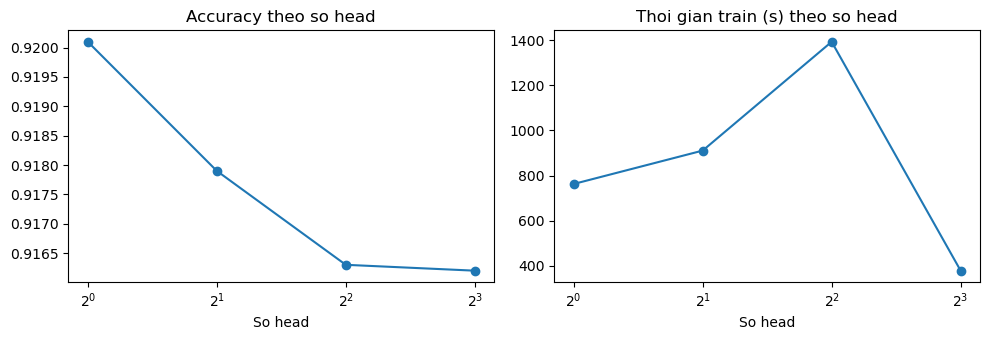

In [7]:
ten = {"transformer_tu_xay": "4 head, co pos (chinh)", "tf_khong_pos": "4 head, KHONG pos",
       "tf_head1": "1 head", "tf_head2": "2 head", "tf_head8": "8 head"}
df = bang_ket_qua(ten)
print(df.to_string(index=False))

heads = df[df["Cach"].str.contains("head") & ~df["Cach"].str.contains("KHONG")].copy()
heads["So head"] = heads["Cach"].str.extract(r"(\d+) head").astype(int)
heads = heads.sort_values("So head")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(heads["So head"], heads["Accuracy"], marker="o"); ax[0].set_title("Accuracy theo so head")
ax[1].plot(heads["So head"], heads["Train (s)"], marker="o"); ax[1].set_title("Thoi gian train (s) theo so head")
for a in ax: a.set_xscale("log", base=2); a.set_xlabel("So head")
fig.tight_layout(); fig.savefig(REPORTS / "khao_sat_head.png", dpi=150); plt.show()